In [1]:
import pandas as pd

df = pd.read_csv('classData.csv')
print(df.head())

   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  


In [2]:
print('Counts of unique combinations of G, C, B, A columns:')
print(df[['G', 'C', 'B', 'A']].value_counts().sort_index())

Counts of unique combinations of G, C, B, A columns:
G  C  B  A
0  0  0  0    2365
   1  1  0    1004
         1    1096
1  0  0  1    1129
      1  1    1134
   1  1  1    1133
Name: count, dtype: int64


In [3]:
def assign_class_label(row):
    g, c, b, a = row['G'], row['C'], row['B'], row['A']
    if g == 0 and c == 0 and b == 0 and a == 0:
        return 0
    elif g == 1 and c == 0 and b == 0 and a == 1:
        return 1
    elif g == 0 and c == 0 and b == 1 and a == 1:
        return 2
    elif g == 1 and c == 0 and b == 1 and a == 1:
        return 3
    elif g == 0 and c == 1 and b == 1 and a == 1:
        return 4
    elif g == 1 and c == 1 and b == 1 and a == 1:
        return 5
    else:
        return 6 # For any other unmapped combination

df['class_label'] = df.apply(assign_class_label, axis=1)

print("Value counts for the new 'class_label' column:")
print(df['class_label'].value_counts())

display(df.head())

Value counts for the new 'class_label' column:
class_label
0    2365
3    1134
5    1133
1    1129
4    1096
6    1004
Name: count, dtype: int64


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [4]:
print(df['class_label'].value_counts())

class_label
0    2365
3    1134
5    1133
1    1129
4    1096
6    1004
Name: count, dtype: int64


In [5]:
df = df.drop(columns=['G', 'B', 'C', 'A'])
print(df.head())

           Ia          Ib          Ic        Va        Vb        Vc  \
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815   
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099   
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428   
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570   
4 -643.663617 -224.159427 -132.282815  0.209537 -0.095554 -0.113983   

   class_label  
0            1  
1            1  
2            1  
3            1  
4            1  


In [7]:
import numpy as np

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Identify numerical columns for outlier detection, excluding 'class_label'
numerical_cols = [col for col in df.columns if df[col].dtype != 'object' and col != 'class_label']

print("Outlier detection using IQR method:")
for col in numerical_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"Column '{col}': {len(outliers)} outliers detected.")

Outlier detection using IQR method:
Column 'Ia': 1802 outliers detected.
Column 'Ib': 1216 outliers detected.
Column 'Ic': 2524 outliers detected.
Column 'Va': 1160 outliers detected.
Column 'Vb': 71 outliers detected.
Column 'Vc': 0 outliers detected.


In [8]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Apply outlier capping to numerical columns
print("Applying IQR-based outlier capping...")
for col in numerical_cols:
    df = cap_outliers_iqr(df.copy(), col) # Use .copy() to avoid SettingWithCopyWarning

print("Outliers capped successfully. Displaying the first 5 rows of the modified DataFrame:")
print(df.head())

Applying IQR-based outlier capping...
Outliers capped successfully. Displaying the first 5 rows of the modified DataFrame:
           Ia          Ib          Ic        Va        Vb        Vc  \
0 -151.291812   -9.677452   85.800162  0.400750 -0.132935 -0.267815   
1 -336.186183  -76.283262   18.328897  0.312732 -0.123633 -0.189099   
2 -502.891583 -174.648023  -80.924663  0.265728 -0.114301 -0.151428   
3 -593.941905 -217.703359 -124.891924  0.235511 -0.104940 -0.130570   
4 -640.375860 -224.159427 -132.282815  0.209537 -0.095554 -0.113983   

   class_label  
0            1  
1            1  
2            1  
3            1  
4            1  


In [9]:
print("Checking for null values:")
print(df.isnull().sum())

print("\nChecking data types:")
print(df.info())

Checking for null values:
Ia             0
Ib             0
Ic             0
Va             0
Vb             0
Vc             0
class_label    0
dtype: int64

Checking data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ia           7861 non-null   float64
 1   Ib           7861 non-null   float64
 2   Ic           7861 non-null   float64
 3   Va           7861 non-null   float64
 4   Vb           7861 non-null   float64
 5   Vc           7861 non-null   float64
 6   class_label  7861 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 430.0 KB
None


In [10]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Data after standardization (first 5 rows):")
print(df.head())

Data after standardization (first 5 rows):
         Ia        Ib        Ic        Va        Vb        Vc  class_label
0 -0.414575  0.114491  0.609867  1.513964 -0.427814 -0.891036            1
1 -0.855151 -0.049026  0.103505  1.187246 -0.398131 -0.635362            1
2 -1.252386 -0.290512 -0.641379  1.012772 -0.368351 -0.513005            1
3 -1.469346 -0.396213 -0.971347  0.900605 -0.338482 -0.445259            1
4 -1.579991 -0.412063 -1.026814  0.804192 -0.308529 -0.391383            1


In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('class_label', axis=1)
y = df['class_label']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6288, 6)
X_test shape: (1573, 6)
y_train shape: (6288,)
y_test shape: (1573,)


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(3, 22, 2) # From 3 to 21, stepping by 2 to get odd numbers
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"K = {k}, Accuracy: {accuracy:.4f}")

# Find the best K
best_k_index = accuracies.index(max(accuracies))
best_k = list(k_values)[best_k_index]
best_accuracy = max(accuracies)

print(f"\nThe best K value is {best_k} with an accuracy of {best_accuracy:.4f}")

K = 3, Accuracy: 0.7959
K = 5, Accuracy: 0.7959
K = 7, Accuracy: 0.8341
K = 9, Accuracy: 0.8347
K = 11, Accuracy: 0.8284
K = 13, Accuracy: 0.8252
K = 15, Accuracy: 0.8252
K = 17, Accuracy: 0.8188
K = 19, Accuracy: 0.8195
K = 21, Accuracy: 0.8271

The best K value is 9 with an accuracy of 0.8347


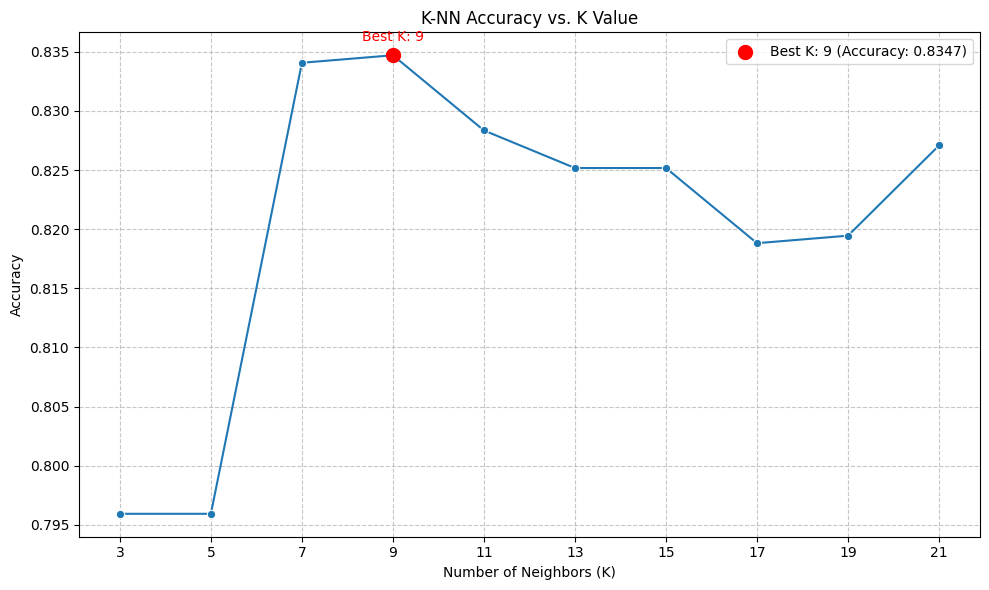

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
results_df = pd.DataFrame({
    'K Value': list(k_values),
    'Accuracy': accuracies
})

plt.figure(figsize=(10, 6))
sns.lineplot(x='K Value', y='Accuracy', data=results_df, marker='o')
plt.title('K-NN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(list(k_values)) # Ensure all K values are shown on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the best K value
plt.scatter(best_k, best_accuracy, color='red', s=100, zorder=5, label=f'Best K: {best_k} (Accuracy: {best_accuracy:.4f})')
plt.annotate(f'Best K: {best_k}', (best_k, best_accuracy), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.legend()
plt.tight_layout()
plt.show()